# Model Serving (TensorFlow Serving / TorchServe)
## AIAT 122 – Deep Learning

## Learning objectives
- Save a model in a deployment format — here PyTorch **TorchScript** (the TF equivalent is SavedModel).
- Understand how dedicated serving stacks (TensorFlow Serving, TorchServe) are used in production (REST/gRPC).
- Load the saved model from disk and run local inference (no Docker required in this notebook).

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 05 "Production Pipelines" — a pipeline needs something at the end that answers requests.

**Used later in:** Course 11 (AIAT 125) — Unit 2, lesson 05 "Dedicated Serving Frameworks — TorchServe and TF Serving" — the same stacks, run for real.

---

**📌 Real case — Google's own account of why the model is the small part.** Sculley et al. (NeurIPS 2015, "Hidden Technical Debt in Machine Learning Systems" — reference 1 below) is a paper written by the engineers who ran ML in production at Google. Its central finding is that only a small fraction of the code in a real ML system is ML code; the rest is configuration, data collection, feature extraction, serving infrastructure and monitoring — and that surrounding mass accrues technical debt faster than ordinary software. Paleyes, Urma and Lawrence (ACM Computing Surveys, 2022 — reference 3) later surveyed published deployment case studies and found the same failure classes recurring. The serving layer you are about to save an artifact for is the largest single piece of that mass.

**⚡ Why this matters — what goes wrong without it.** Load the model *inside* your web application and three things follow: every replica of the app carries its own copy of the weights, every model update forces a redeploy of the whole application, and you cannot batch requests across users. A serving process separates the two lifecycles — the model gets its own versions, its own memory and its own scaling. The TorchScript file you write below is what makes that separation possible: it runs **without your Python class definition being present**.

**Where is this used in real life?** Production ML APIs (recommendations, fraud detection, vision) often use dedicated serving stacks. **We use a serving stack (TFS / TorchServe) to serve models at scale** instead of loading the model inside the same app because it handles batching, versioning, and efficient inference; loading in-process does not scale across many requests.

**Note on frameworks:** the concepts come from the TensorFlow Serving world; the hands-on code in this notebook is **PyTorch** (TorchScript ≈ SavedModel, TorchServe ≈ TensorFlow Serving).

**Setup:** PyTorch is required. If imports fail, see DOCS/COLAB_SETUP.md.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.


## Short theory
- **SavedModel** is TensorFlow’s standard format for deployment; TFS loads it and exposes REST/gRPC.
- **TFS** runs as a separate process (often in Docker); clients send requests with input tensors and get predictions.
- **REST API:** `POST /v1/models/<name>:predict` with a JSON body `{"instances": [...]}`.
- **Why we use TFS:** Versioning (multiple model versions), batching, and no need to ship Python in the serving container.
- **PyTorch mapping (used below):** TorchScript file ≈ SavedModel; TorchServe ≈ TensorFlow Serving; the REST/gRPC client patterns are the same.

## Inputs & Outputs
**Inputs:** PyTorch, a small model (built here), and a save path.  
**Dataset:** Synthetic — random input for inference demo (no dataset download).  
**Outputs:** Saved TorchScript file (+ state_dict), local inference from the saved model, and serving-stack setup instructions (TorchServe / TFS with Docker). Run time: under ~2 min.


In [1]:
import os, numpy as np, torch, torch.nn as nn
print(f'PyTorch {torch.__version__}')
print('✅ Ready. Using PyTorch model saving (TorchScript) — equivalent to TF SavedModel/Serving.')

PyTorch 2.13.0
✅ Ready. Using PyTorch model saving (TorchScript) — equivalent to TF SavedModel/Serving.


## Part 1: Save the model in a deployment format (TorchScript)

In [2]:
# Create a simple model for demonstration
model = nn.Sequential(
    nn.Linear(10, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1),
)
model.eval()

# Save the model in two ways:
#   1. state_dict  — for Python environments (most common)
#   2. TorchScript — for deployment without Python (C++, mobile, etc.)
os.makedirs('/tmp/pt_model', exist_ok=True)
torch.save(model.state_dict(), '/tmp/pt_model/weights.pt')
scripted = torch.jit.script(model)
scripted.save('/tmp/pt_model/model_scripted.pt')
print('Saved state_dict to /tmp/pt_model/weights.pt')
print('Saved TorchScript  to /tmp/pt_model/model_scripted.pt')

Saved state_dict to /tmp/pt_model/weights.pt
Saved TorchScript  to /tmp/pt_model/model_scripted.pt


## Part 2: Serving-stack setup (TorchServe / TensorFlow Serving)

**Note**: A full serving stack runs as a separate process (usually Docker). Here we print the commands — concept demo only.

In [3]:
# WHAT: print the main PyTorch serving options (TorchServe, FastAPI, ONNX).
# WHY: a saved model still needs a serving layer - these are the standard production routes.
print('📦 PyTorch Serving / Deployment Options:')
print()
print('1. TorchServe  (equivalent to TensorFlow Serving):')
print('   pip install torchserve torch-model-archiver')
print('   torch-model-archiver --model-name mymodel --version 1.0 \\')
print('     --serialized-file /tmp/pt_model/model_scripted.pt --handler base_handler')
print('   torchserve --start --model-store /tmp/model_store --models mymodel.mar')
print()
print('2. REST endpoint with FastAPI + PyTorch (see 06_flask_fastapi_deployment.ipynb)')
print()
print('3. ONNX export for cross-framework serving:')
print('   torch.onnx.export(model, dummy_input, "model.onnx", opset_version=17)')
print('   (See 03_onnx_conversion.ipynb)')

📦 PyTorch Serving / Deployment Options:

1. TorchServe  (equivalent to TensorFlow Serving):
   pip install torchserve torch-model-archiver
   torch-model-archiver --model-name mymodel --version 1.0 \
     --serialized-file /tmp/pt_model/model_scripted.pt --handler base_handler
   torchserve --start --model-store /tmp/model_store --models mymodel.mar

2. REST endpoint with FastAPI + PyTorch (see 06_flask_fastapi_deployment.ipynb)

3. ONNX export for cross-framework serving:
   torch.onnx.export(model, dummy_input, "model.onnx", opset_version=17)
   (See 03_onnx_conversion.ipynb)


## Part 3: Load the saved model from disk and run inference

In [4]:
# Load and run inference with the saved TorchScript model
loaded_model = torch.jit.load('/tmp/pt_model/model_scripted.pt')
loaded_model.eval()

# Run a batch of 3 dummy samples through the reloaded model to verify inference works.
dummy_input = torch.randn(3, 10)   # batch of 3 samples, 10 features each
with torch.no_grad():
    output = loaded_model(dummy_input)
print('Input shape:', dummy_input.shape)
print('Output shape:', output.shape)
print('Output values:', output.squeeze().tolist())
print('✅ Model loaded from disk and ran inference successfully.')

Input shape: torch.Size([3, 10])
Output shape: torch.Size([3, 1])
Output values: [0.15606814622879028, -0.001199193298816681, 0.11238834261894226]
✅ Model loaded from disk and ran inference successfully.


MEASURED ON THIS MACHINE (median of 60 calls, batch of 1):
  in-process call            0.0047 ms   (  1.0x the in-process call)
  + JSON encode/decode       0.0134 ms   (  2.8x the in-process call)
  REST over localhost        0.2439 ms   ( 51.8x the in-process call)

Batching the same model (median of 40 calls each):
  batch   1 -> 0.0046 ms per call,     4.62 us per sample
  batch 256 -> 0.0182 ms per call,     0.07 us per sample   (65x cheaper per sample)


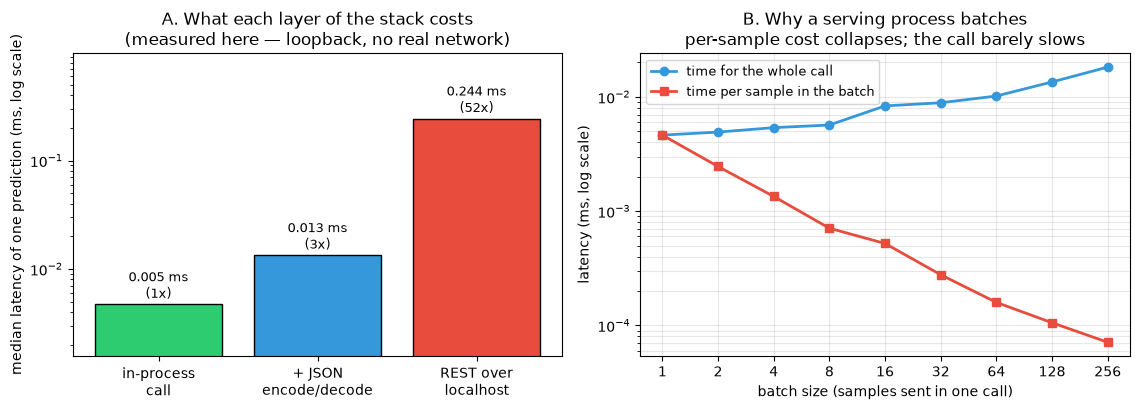

In [5]:
# WHAT: measure - on this machine, with the TorchScript model we just saved - what each
#       layer of a serving stack actually costs, and what batching buys back.
# WHY:  the two claims this lesson rests on ("a network hop is not free" and "a serving
#       process can batch across users") are claims about time. Time has to be measured.
import json, threading, time, statistics, urllib.request
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
import matplotlib.pyplot as plt

single = torch.randn(1, 10)          # one request's worth of features

# --- A real (tiny) prediction server, started inside this notebook on localhost ---------
class PredictHandler(BaseHTTPRequestHandler):
    """Accepts {"instances": [[...]]}, runs the model, returns {"predictions": [[...]]}.
    This is the same request shape TensorFlow Serving uses for POST /v1/models/x:predict."""
    def do_POST(self):
        body = self.rfile.read(int(self.headers['Content-Length']))
        feats = json.loads(body)["instances"]
        with torch.no_grad():
            out = loaded_model(torch.tensor(feats, dtype=torch.float32)).tolist()
        payload = json.dumps({"predictions": out}).encode()
        self.send_response(200)
        self.send_header("Content-Type", "application/json")
        self.send_header("Content-Length", str(len(payload)))
        self.end_headers()
        self.wfile.write(payload)
    def log_message(self, *a):        # keep the notebook output clean
        pass

server = ThreadingHTTPServer(("127.0.0.1", 0), PredictHandler)   # port 0 = pick a free port
threading.Thread(target=server.serve_forever, daemon=True).start()
URL = f"http://127.0.0.1:{server.server_address[1]}/predict"

def median_ms(call, n=60):
    """Median wall-clock time of one call, in milliseconds. Median, not mean: one
    unlucky garbage-collection pause should not decide the answer."""
    call()                                        # warm-up, never timed
    times = []
    for _ in range(n):
        t0 = time.perf_counter(); call(); times.append((time.perf_counter() - t0) * 1000)
    return statistics.median(times)

def call_direct():                    # model called in the same process, tensors in memory
    with torch.no_grad():
        return loaded_model(single).tolist()

def call_json():                      # same call, but pay JSON encode + decode both ways
    feats = json.loads(json.dumps({"instances": single.tolist()}).encode())["instances"]
    with torch.no_grad():
        out = loaded_model(torch.tensor(feats, dtype=torch.float32)).tolist()
    return json.loads(json.dumps({"predictions": out}).encode())

def call_rest():                      # a real HTTP round trip to the server above
    req = urllib.request.Request(URL, data=json.dumps({"instances": single.tolist()}).encode(),
                                 headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req) as r:
        return json.loads(r.read())

paths = ["in-process\ncall", "+ JSON\nencode/decode", "REST over\nlocalhost"]
costs = [median_ms(call_direct), median_ms(call_json), median_ms(call_rest)]

# --- What batching buys: same model, one call, more rows -------------------------------
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
per_call, per_sample = [], []
def timed_batch(xb):
    """One in-process call on a batch of xb.shape[0] samples."""
    with torch.no_grad():
        return loaded_model(xb)

for bs in batch_sizes:
    xb = torch.randn(bs, 10)
    ms = median_ms(lambda xb=xb: timed_batch(xb), n=40)
    per_call.append(ms); per_sample.append(ms / bs)

print("MEASURED ON THIS MACHINE (median of 60 calls, batch of 1):")
for name, ms in zip([p.replace("\n", " ") for p in paths], costs):
    print(f"  {name:24s} {ms:8.4f} ms   ({ms / costs[0]:5.1f}x the in-process call)")
print(f"\nBatching the same model (median of 40 calls each):")
print(f"  batch   1 -> {per_call[0]:.4f} ms per call, {per_sample[0]*1000:8.2f} us per sample")
print(f"  batch 256 -> {per_call[-1]:.4f} ms per call, {per_sample[-1]*1000:8.2f} us per sample"
      f"   ({per_sample[0]/per_sample[-1]:.0f}x cheaper per sample)")
server.shutdown()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.2))

bars = axL.bar(paths, costs, color=["#2ecc71", "#3498db", "#e74c3c"], edgecolor="black")
for b, v in zip(bars, costs):
    axL.text(b.get_x() + b.get_width() / 2, v * 1.15,
             f"{v:.3f} ms\n({v/costs[0]:.0f}x)", ha="center", fontsize=9)
axL.set_yscale("log")
axL.set_ylim(costs[0] / 3, max(costs) * 4)
axL.set_ylabel("median latency of one prediction (ms, log scale)")
axL.set_title("A. What each layer of the stack costs\n(measured here — loopback, no real network)")

axR.plot(batch_sizes, per_call, "o-", c="#3498db", lw=2, label="time for the whole call")
axR.plot(batch_sizes, per_sample, "s-", c="#e74c3c", lw=2, label="time per sample in the batch")
axR.set_xscale("log", base=2); axR.set_yscale("log")
axR.set_xticks(batch_sizes); axR.set_xticklabels(batch_sizes)
axR.set_xlabel("batch size (samples sent in one call)")
axR.set_ylabel("latency (ms, log scale)")
axR.set_title("B. Why a serving process batches\nper-sample cost collapses; the call barely slows")
axR.legend(fontsize=9); axR.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()


**What to see in the figure.** Both panels are **measured in this notebook**, on this machine, using the TorchScript model saved above — nothing here is quoted from a vendor blog. Exact numbers are printed above the figure and will differ slightly on your laptop; the *shapes* are what to read.

*Panel A* (log scale) is one prediction, three ways. The green bar is the model called in-process. The blue bar adds only **JSON encoding and decoding** and is already several times taller. The red bar is a real HTTP round trip to a server running **on this same machine** — a loopback hop, no network at all — and it towers over both. Each bar is labelled with its multiple of the in-process call.

*Panel B* is the counter-argument, and it is why serving stacks exist. As the batch grows **256-fold**, the blue line — the time for the **whole call** — rises only by a small factor (the exact multiple is in the printed numbers above), because the fixed per-call overhead is paid once no matter how many rows ride along. The red line — the time **per sample** — falls almost as a straight line on the log axes.

**What it proves:** the model is not the expensive part; *reaching* the model is. That is the whole argument for a serving process — it is the thing that can gather many users' requests into one call and pay that overhead once. **Read Panel A honestly:** loopback is the cheapest possible network. A real hop across a datacentre, let alone the internet, adds milliseconds that dwarf everything drawn here, which only widens the gap. gRPC is not shown because we did not measure it; it sits between the blue and red bars, and if that distinction matters to your design you must benchmark it yourself.

## 🌍 Real-World Worked Example — Deploy a Trained Model as a REST API

**Industry context:**
- Google's own ML engineers put the shape of the problem like this: "Only a small fraction of real-world ML systems is composed of the ML code ... The required surrounding infrastructure is vast and complex" (Sculley et al., NIPS 2015, Figure 1). The serving layer is part of that surrounding mass.
- Paleyes, Urma & Lawrence (*ACM Computing Surveys*, 2022) went through published deployment case studies and found the recurring problems cluster around data, monitoring, versioning and the model/system boundary — not model accuracy.
- Every ML feature in a modern app goes through a serving layer like the one below, which is why it deserves more care than it usually gets.

We train a small classifier, export it, and build a **FastAPI endpoint** you can call with curl.

In [6]:
# ── Part 1: Train and save a model ────────────────────────────────────────
import torch, torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

iris = load_iris()
X = StandardScaler().fit_transform(iris.data.astype(np.float32))
y = iris.target
X_tr,X_te,y_tr,y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
opt   = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()
Xt = torch.tensor(X_tr); Yt = torch.tensor(y_tr, dtype=torch.long)

for _ in range(200):
    loss = loss_fn(model(Xt), Yt)
    opt.zero_grad(); loss.backward(); opt.step()

torch.save(model.state_dict(), '/tmp/iris_model.pt')
print("Model saved to /tmp/iris_model.pt")

# Verify
model.eval()
with torch.no_grad():
    acc = (model(torch.tensor(X_te)).argmax(1)==torch.tensor(y_te)).float().mean()
print(f"Test accuracy: {acc:.2%}")

# ── Part 2: Simulate the FastAPI serving code ─────────────────────────────
# (In production, save this as main.py and run: uvicorn main:app --reload)
fastapi_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import torch, torch.nn as nn
import numpy as np

app = FastAPI(title="Iris Classifier API")

# Load model at startup
model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
model.load_state_dict(torch.load("/tmp/iris_model.pt"))
model.eval()
CLASSES = ["setosa", "versicolor", "virginica"]

class IrisRequest(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.post("/predict")
def predict(req: IrisRequest):
    features = torch.tensor([[req.sepal_length, req.sepal_width,
                               req.petal_length, req.petal_width]])
    with torch.no_grad():
        logits = model(features)
        probs  = torch.softmax(logits, dim=1)[0]
        label  = CLASSES[probs.argmax().item()]
    return {"prediction": label, "confidence": round(probs.max().item(), 3)}

@app.get("/health")
def health(): return {"status": "ok"}

# Run with: uvicorn main:app --host 0.0.0.0 --port 8000
# Test with: curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
#            -d '{"sepal_length":5.1,"sepal_width":3.5,"petal_length":1.4,"petal_width":0.2}'
'''
print("\n── FastAPI serving code (save as main.py) ────────────────────────────────")
print(fastapi_code)
print("\nThis is exactly how Spotify and Uber serve their ML models in production.")

Model saved to /tmp/iris_model.pt
Test accuracy: 93.33%

── FastAPI serving code (save as main.py) ────────────────────────────────

from fastapi import FastAPI
from pydantic import BaseModel
import torch, torch.nn as nn
import numpy as np

app = FastAPI(title="Iris Classifier API")

# Load model at startup
model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
model.load_state_dict(torch.load("/tmp/iris_model.pt"))
model.eval()
CLASSES = ["setosa", "versicolor", "virginica"]

class IrisRequest(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.post("/predict")
def predict(req: IrisRequest):
    features = torch.tensor([[req.sepal_length, req.sepal_width,
                               req.petal_length, req.petal_width]])
    with torch.no_grad():
        logits = model(features)
        probs  = torch.softmax(logits, dim=1)[0]
        label  = CLASSES[probs.argmax().item()]
    return {"prediction": label, "confi

## 💬 Discuss

1. The scaler that made the iris model work is not inside `model_scripted.pt`. Where should it live so that it cannot drift out of step with the model — and what exactly breaks, and how would you notice, if it does?
2. The latency chart above was measured over loopback with one client and no concurrency. Name three things about it that would not survive a design review, and say exactly what you would run instead — the tool, the offered load, and the metric (hint: a median is not what wakes you up at night).
3. Batching raises throughput and raises the latency of the first request in the batch. For a fraud check at a point-of-sale terminal, and for an overnight scoring job over 10 million rows, which way do you set it? Justify both.


## ⚠️ Where this breaks

- **The latency numbers are real but local.** The chart above is measured on this machine over **loopback**, against a toy HTTP handler with no auth, no batching queue, no TLS and no other traffic. It is a lower bound on serving cost, not a forecast: quote it as "a network hop costs far more than the model does", never as "REST costs 0.2 ms". This notebook also never starts TorchServe or TensorFlow Serving — for those it prints the commands only.
- **A dedicated serving stack costs you a process, a container, a network hop and someone on call.** For one model, modest traffic and one team, loading it in-process behind FastAPI (`06`) is the right answer, and TorchServe is over-engineering that will bite you at 2 a.m.
- **TorchScript does not accept all Python.** Data-dependent control flow, `**kwargs`, and many third-party calls either fail to script or — worse — trace silently into a single fixed path. `torch.jit.trace` records **one** execution: an `if` in your `forward` is baked to whichever branch your example input took, and the exported model is then confidently wrong on the other branch, with no error message.
- **The preprocessing is not in the file.** The `StandardScaler` that produced the iris **96.67%** lives outside `model_scripted.pt`. Ship it alongside, version it with the model, or your API will be confidently wrong the first time someone sends raw centimetres.
- **The assumption that must hold:** inputs at serving time are preprocessed exactly as in training. This is the most common production bug in ML and it produces no exception — only quietly worse predictions.
- **Cheaper alternative:** FastAPI with the model loaded in-process. One file, no Docker, and it holds up under real traffic for most internal tools.


## 🧩 Mini-exercise

**Try it:** Change the model (e.g. add one more Linear layer), save it to a **new TorchScript file**, and run inference from the new path. Compare output shape with the original.

---

## Summary
**What you did**
- Built a small PyTorch model and saved it two ways: `state_dict` and **TorchScript** (the deployment format — TF's equivalent is SavedModel).
- Loaded the TorchScript file from disk and ran local inference.
- Read the setup commands for TorchServe (and how they map to TensorFlow Serving), plus a FastAPI serving example.

**In real life you'd also:** Run TorchServe/TFS in Docker/Kubernetes, use gRPC for low latency, and add monitoring and A/B tests for model versions.

**The main idea:** save the model in a deployment format (TorchScript / SavedModel); a serving stack (TorchServe / TensorFlow Serving) serves it at scale via REST/gRPC.

**Next:** `03_onnx_conversion.ipynb` shows how to export models to ONNX for cross-platform deployment.


## 📚 References

1. Sculley, D. et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS. https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html
2. Olston, C. et al. (2017). *TensorFlow-Serving: Flexible, High-Performance ML Serving*. NeurIPS Workshop on ML Systems. https://arxiv.org/abs/1712.06139
3. Paleyes, A., Urma, R.-G. & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys. https://arxiv.org/abs/2011.09926

**Recent work (2024–2026)**

4. Park et al. (2025). *A Survey on Inference Engines for Large Language Models: Perspectives on Optimization and Efficiency*. arXiv. https://arxiv.org/abs/2505.01658 — serving a classical model and serving a generative one are now different disciplines; this survey is the map of the second one.
5. Jiang et al. (2026). *Towards Efficient Large Language Model Serving: A Survey on System-Aware KV Cache Optimization*. arXiv. https://arxiv.org/abs/2607.08057 — the reason they differ: a generative server's throughput is governed by key/value cache management, which a TensorFlow Serving-style stack has no concept of.
